# Employee Attrition Prediction using Machine Learning

### Internship Project – Week 2

**Name:** Varad Khatavkar  
**Project:** Employee Attrition Prediction using Machine Learning  
**Dataset:** IBM HR Analytics Employee Attrition Dataset  
**Tools Used:** Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn, Google Colab

---

### Objective

The objective of this project is to build a machine learning model that predicts whether an employee is likely to leave the company based on various factors such as job satisfaction, monthly income, work-life balance, years at the company, and performance rating. The analysis also aims to provide actionable business insights to help HR teams improve employee retention.

In [1]:
# Import Required Libraries

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Model Evaluation
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Plot settings
%matplotlib inline

# Better plot appearance
plt.style.use('ggplot')

print("All libraries imported successfully.")

All libraries imported successfully.


In [2]:

from google.colab import files

# Upload CSV file
uploaded = files.upload()

Saving WA_Fn-UseC_-HR-Employee-Attrition.csv to WA_Fn-UseC_-HR-Employee-Attrition (2).csv


In [3]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


## Task 1: Data Loading and Exploration

In [4]:
# Display the first 10 rows of the dataset
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [5]:
# Check the number of rows and columns
print(f"Number of Rows    : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1]}")

Number of Rows    : 1470
Number of Columns : 35


In [6]:
# Display all column names
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [7]:
# Display unique values in the target column
print("Target Column: Attrition")
print(df["Attrition"].unique())

Target Column: Attrition
['Yes' 'No']


In [8]:
# Count employees who stayed and left
attrition_counts = df["Attrition"].value_counts()

print(attrition_counts)

Attrition
No     1233
Yes     237
Name: count, dtype: int64


In [9]:
# Calculate attrition percentage
attrition_rate = (attrition_counts["Yes"] / len(df)) * 100

print(f"Overall Attrition Rate: {attrition_rate:.2f}%")

Overall Attrition Rate: 16.12%


In [10]:
# Separate numerical and categorical columns

numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = df.select_dtypes(include=["object"]).columns

print(f"Number of Numerical Columns   : {len(numerical_cols)}")
print(f"Number of Categorical Columns : {len(categorical_cols)}")

Number of Numerical Columns   : 26
Number of Categorical Columns : 9


In [11]:
print("Numerical Columns:")
print(list(numerical_cols))

print("\nCategorical Columns:")
print(list(categorical_cols))

Numerical Columns:
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Categorical Columns:
['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


### Observation

The dataset contains 1,470 employee records with an overall attrition rate of approximately **16.12%**. Since only about one out of every six employees has left the company, the target variable is **imbalanced**. This imbalance can bias machine learning models toward predicting the majority class, so techniques such as using `class_weight='balanced'` will be applied during model training.

## Task 2: Data Cleaning and Preprocessing

In [12]:
# Check for missing values in each column
missing_values = df.isnull().sum()

print(missing_values)

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [13]:
# Total missing values in the dataset
print("Total Missing Values:", df.isnull().sum().sum())

Total Missing Values: 0


In [14]:
# Check for duplicate rows
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


### Observation

The dataset does not contain duplicate records, indicating that each employee entry is unique.

In [15]:
# Drop irrelevant columns
df.drop(columns=['EmployeeNumber', 'Over18', 'StandardHours'], inplace=True)

print("Columns dropped successfully!")

Columns dropped successfully!


In [16]:
print("Updated Dataset Shape:", df.shape)

Updated Dataset Shape: (1470, 32)


In [17]:
# Convert Attrition column to binary values
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

# Verify conversion
df['Attrition'].value_counts()

,count
Attrition,
0,1233
1,237


In [18]:
# Separate numerical and categorical columns

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

print("Numerical Columns:", len(numerical_cols))
print("Categorical Columns:", len(categorical_cols))

Numerical Columns: 25
Categorical Columns: 7


In [19]:
# One-Hot Encode categorical features

df_encoded = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

print("Encoded Dataset Shape:", df_encoded.shape)

Encoded Dataset Shape: (1470, 46)


In [20]:
# Separate features (X) and target (y)

X = df_encoded.drop("Attrition", axis=1)
y = df_encoded["Attrition"]

print("Feature Matrix Shape :", X.shape)
print("Target Vector Shape  :", y.shape)

Feature Matrix Shape : (1470, 45)
Target Vector Shape  : (1470,)


In [21]:
# Create a copy of the feature matrix
X_scaled = X.copy()

# Identify only the original numerical feature columns (excluding Attrition)
num_cols_to_scale = [col for col in numerical_cols if col != 'Attrition']

# Initialize StandardScaler
scaler = StandardScaler()

# Scale only numerical columns
X_scaled[num_cols_to_scale] = scaler.fit_transform(X_scaled[num_cols_to_scale])

print("Feature scaling completed successfully!")

Feature scaling completed successfully!


## Task 3: Exploratory Data Analysis (EDA)

In [22]:
# Attrition rate by Department

department_attrition = (
    df.groupby('Department')['Attrition']
      .mean()
      .sort_values(ascending=False) * 100
)

print(department_attrition)

Department
Sales                     20.627803
Human Resources           19.047619
Research & Development    13.839750
Name: Attrition, dtype: float64


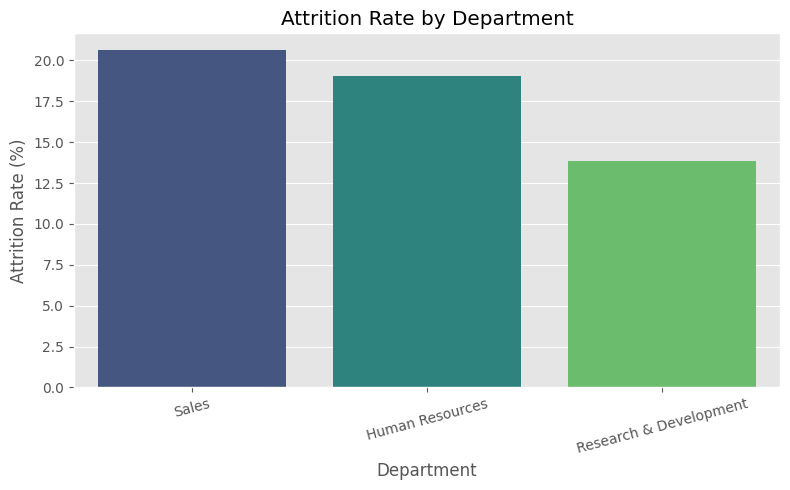

In [23]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=department_attrition.index,
    y=department_attrition.values,
    palette='viridis'
)

plt.title("Attrition Rate by Department")
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=15)

plt.tight_layout()

# Save chart
plt.savefig("chart1_department_attrition.png", dpi=300)

plt.show()

In [24]:
jobrole_attrition = (
    df.groupby('JobRole')['Attrition']
      .mean()
      .sort_values(ascending=False) * 100
)

print(jobrole_attrition)

JobRole
Sales Representative         39.759036
Laboratory Technician        23.938224
Human Resources              23.076923
Sales Executive              17.484663
Research Scientist           16.095890
Manufacturing Director        6.896552
Healthcare Representative     6.870229
Manager                       4.901961
Research Director             2.500000
Name: Attrition, dtype: float64


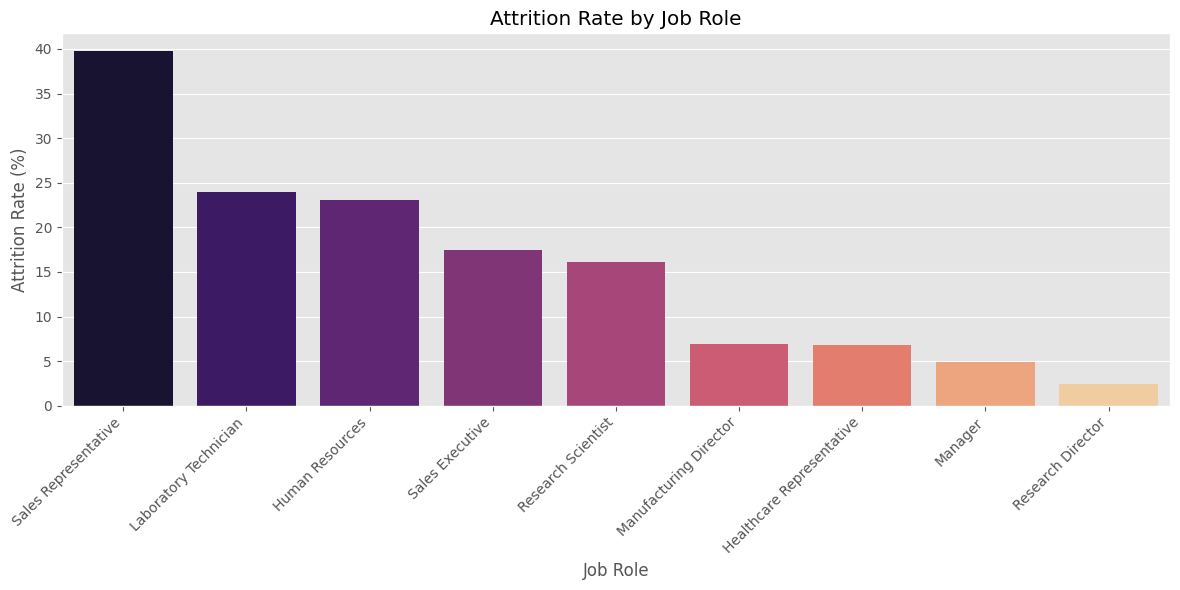

In [25]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=jobrole_attrition.index,
    y=jobrole_attrition.values,
    palette='magma'
)

plt.title("Attrition Rate by Job Role")
plt.xlabel("Job Role")
plt.ylabel("Attrition Rate (%)")

plt.xticks(rotation=45, ha='right')

plt.tight_layout()

plt.savefig("chart2_jobrole_attrition.png", dpi=300)

plt.show()

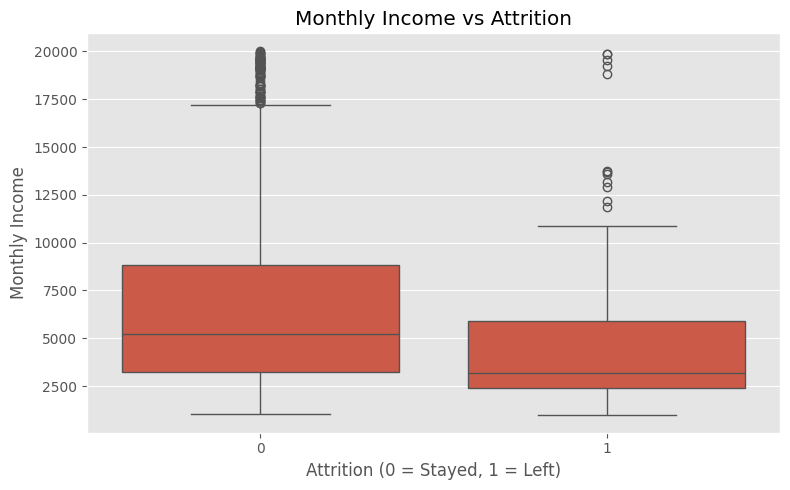

In [26]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Attrition',
    y='MonthlyIncome',
    data=df
)

plt.title("Monthly Income vs Attrition")

plt.xlabel("Attrition (0 = Stayed, 1 = Left)")
plt.ylabel("Monthly Income")

plt.tight_layout()

plt.savefig("chart3_income_attrition.png", dpi=300)

plt.show()

In [27]:
# Attrition rate by Work-Life Balance

worklife_attrition = (
    df.groupby('WorkLifeBalance')['Attrition']
      .mean()
      .sort_index() * 100
)

print(worklife_attrition)

WorkLifeBalance
1    31.250000
2    16.860465
3    14.221725
4    17.647059
Name: Attrition, dtype: float64


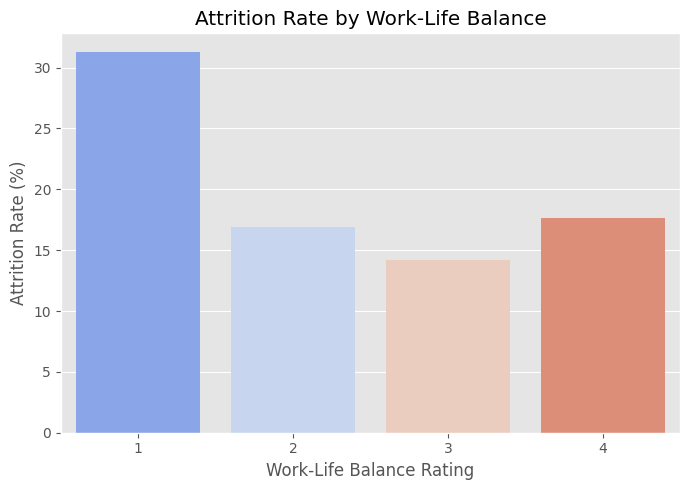

In [28]:
plt.figure(figsize=(7,5))

sns.barplot(
    x=worklife_attrition.index,
    y=worklife_attrition.values,
    palette='coolwarm'
)

plt.title("Attrition Rate by Work-Life Balance")
plt.xlabel("Work-Life Balance Rating")
plt.ylabel("Attrition Rate (%)")

plt.tight_layout()

plt.savefig("chart4_worklife_attrition.png", dpi=300)

plt.show()

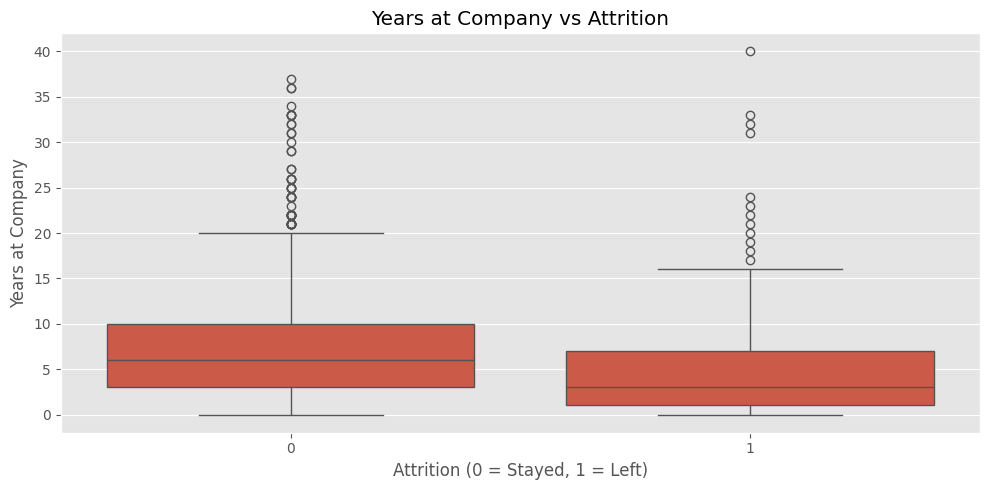

In [29]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x='Attrition',
    y='YearsAtCompany',
    data=df
)

plt.title("Years at Company vs Attrition")
plt.xlabel("Attrition (0 = Stayed, 1 = Left)")
plt.ylabel("Years at Company")

plt.tight_layout()

plt.savefig("chart5_years_company.png", dpi=300)

plt.show()

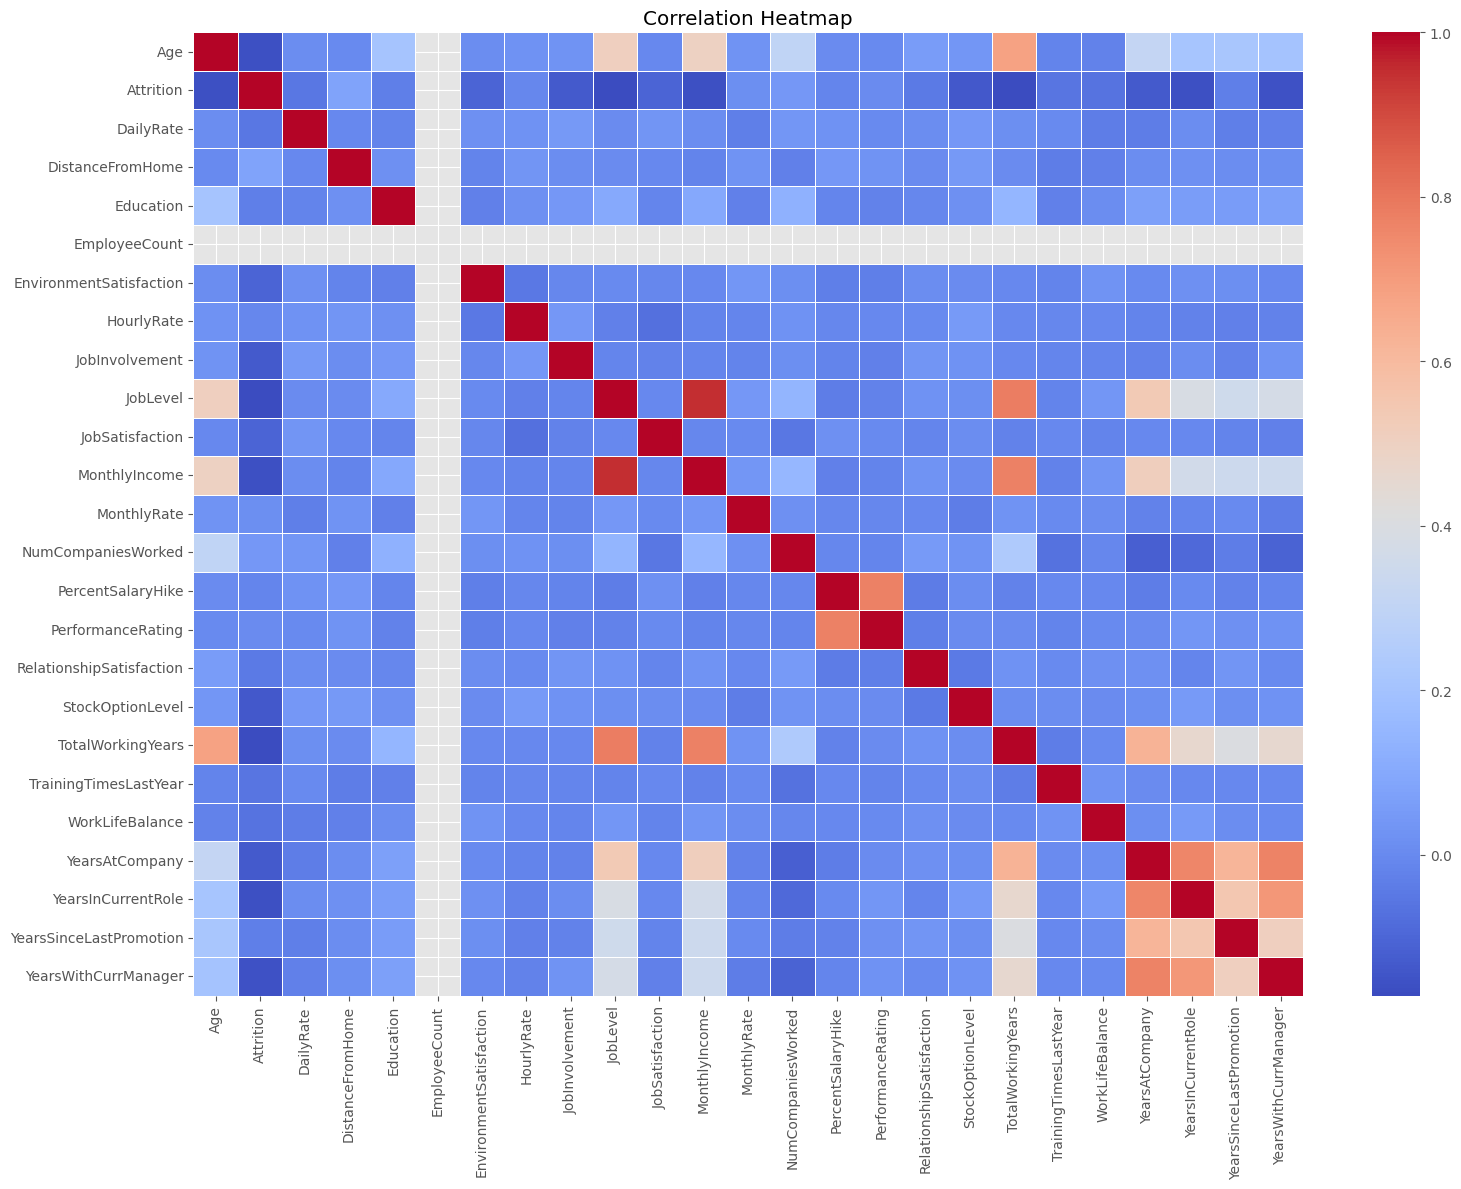

In [30]:
plt.figure(figsize=(16,12))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.show()

## Task 4: Model Building and Comparison

In [31]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set:", X_train.shape)
print("Testing Set :", X_test.shape)

Training Set: (1176, 45)
Testing Set : (294, 45)


In [32]:
# Logistic Regression

lr_model = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)

lr_model.fit(X_train, y_train)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [33]:
# Random Forest Classifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [34]:
# Gradient Boosting Classifier

gb_model = GradientBoostingClassifier(
    random_state=42
)

gb_model.fit(X_train, y_train)

print("Gradient Boosting trained successfully!")

Gradient Boosting trained successfully!


In [35]:
# Predictions

lr_pred = lr_model.predict(X_test)
rf_pred = rf_model.predict(X_test)
gb_pred = gb_model.predict(X_test)

print("Predictions generated successfully!")

Predictions generated successfully!


## Task 5: Model Evaluation

In [36]:
from sklearn.metrics import roc_curve

In [37]:
def evaluate_model(model, y_true, y_pred, X_test):
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, model.predict_proba(X_test)[:,1])

    return precision, recall, f1, roc_auc

In [38]:
lr_metrics = evaluate_model(lr_model, y_test, lr_pred, X_test)
rf_metrics = evaluate_model(rf_model, y_test, rf_pred, X_test)
gb_metrics = evaluate_model(gb_model, y_test, gb_pred, X_test)

In [39]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Precision":[lr_metrics[0],rf_metrics[0],gb_metrics[0]],
    "Recall":[lr_metrics[1],rf_metrics[1],gb_metrics[1]],
    "F1 Score":[lr_metrics[2],rf_metrics[2],gb_metrics[2]],
    "ROC AUC":[lr_metrics[3],rf_metrics[3],gb_metrics[3]]
})

comparison

,Model,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.356322,0.659574,0.462687,0.803601
1,Random Forest,0.500000,0.063830,0.113208,0.775218
2,Gradient Boosting,0.611111,0.234043,0.338462,0.793781


In [40]:
print("========== Logistic Regression ==========")
print(classification_report(y_test, lr_pred))

print("\n========== Random Forest ==========")
print(classification_report(y_test, rf_pred))

print("\n========== Gradient Boosting ==========")
print(classification_report(y_test, gb_pred))

========== Logistic Regression ==========
              precision    recall  f1-score   support

           0       0.92      0.77      0.84       247
           1       0.36      0.66      0.46        47

    accuracy                           0.76       294
   macro avg       0.64      0.72      0.65       294
weighted avg       0.83      0.76      0.78       294


========== Random Forest ==========
              precision    recall  f1-score   support

           0       0.85      0.99      0.91       247
           1       0.50      0.06      0.11        47

    accuracy                           0.84       294
   macro avg       0.67      0.53      0.51       294
weighted avg       0.79      0.84      0.78       294


========== Gradient Boosting ==========
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       247
           1       0.61      0.23      0.34        47

    accuracy                           0.85       294
   macro

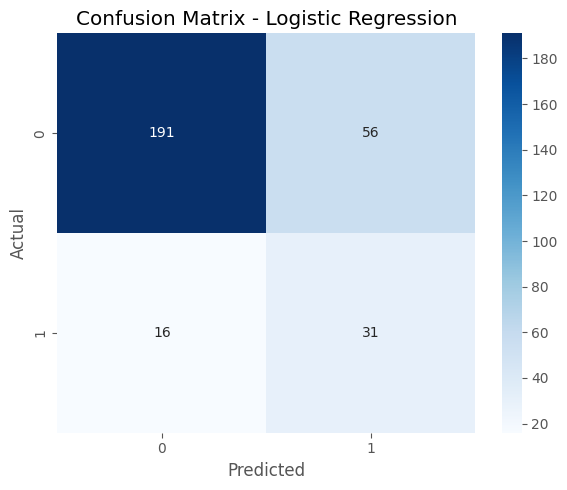

In [41]:
plt.figure(figsize=(6,5))

cm = confusion_matrix(y_test, lr_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.tight_layout()

plt.savefig("chart6_confusion_matrix.png", dpi=300)

plt.show()

In [42]:
# Feature Importance using Logistic Regression Coefficients

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': abs(lr_model.coef_[0])
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
44,OverTime_Yes,1.626169
24,BusinessTravel_Travel_Frequently,1.596964
35,JobRole_Laboratory Technician,1.571637
41,JobRole_Sales Representative,1.264294
38,JobRole_Research Director,1.112054
31,EducationField_Other,1.020279
25,BusinessTravel_Travel_Rarely,0.903722
43,MaritalStatus_Single,0.864502
34,JobRole_Human Resources,0.670991
17,TotalWorkingYears,0.612480


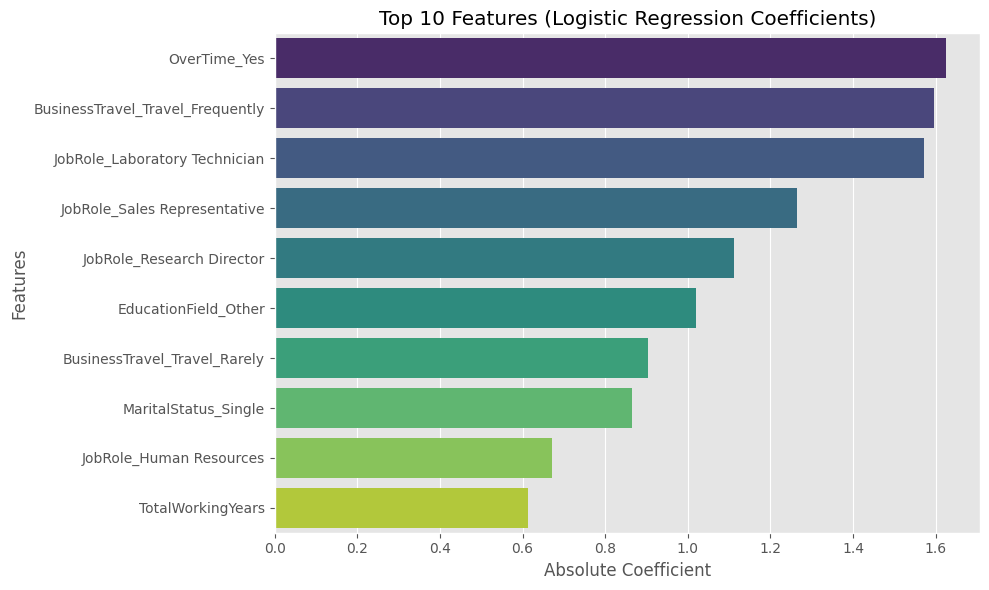

In [43]:
plt.figure(figsize=(10,6))

top10 = feature_importance.head(10)

sns.barplot(
    data=top10,
    x='Importance',
    y='Feature',
    palette='viridis'
)

plt.title("Top 10 Features (Logistic Regression Coefficients)")
plt.xlabel("Absolute Coefficient")
plt.ylabel("Features")

plt.tight_layout()

plt.savefig("chart7_feature_importance.png", dpi=300)

plt.show()

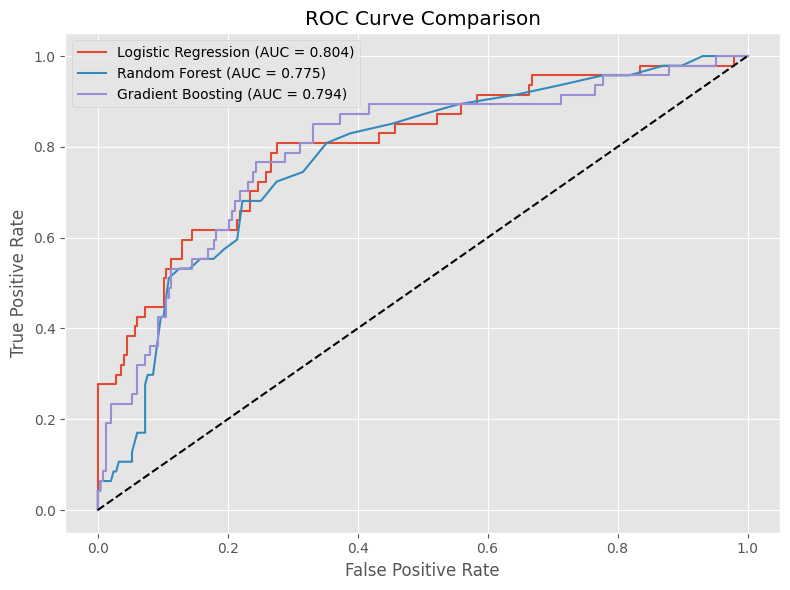

In [44]:
# Predicted probabilities
lr_prob = lr_model.predict_proba(X_test)[:,1]
rf_prob = rf_model.predict_proba(X_test)[:,1]
gb_prob = gb_model.predict_proba(X_test)[:,1]

# ROC Curves
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
gb_fpr, gb_tpr, _ = roc_curve(y_test, gb_prob)

plt.figure(figsize=(8,6))

plt.plot(lr_fpr, lr_tpr,
         label=f'Logistic Regression (AUC = {lr_metrics[3]:.3f})')

plt.plot(rf_fpr, rf_tpr,
         label=f'Random Forest (AUC = {rf_metrics[3]:.3f})')

plt.plot(gb_fpr, gb_tpr,
         label=f'Gradient Boosting (AUC = {gb_metrics[3]:.3f})')

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()

plt.tight_layout()

plt.savefig("chart8_roc_curve.png", dpi=300)

plt.show()

In [45]:
print("Top 10 Features Influencing Employee Attrition\n")

top10.reset_index(drop=True)

Top 10 Features Influencing Employee Attrition



,Feature,Importance
0,OverTime_Yes,1.626169
1,BusinessTravel_Travel_Frequently,1.596964
2,JobRole_Laboratory Technician,1.571637
3,JobRole_Sales Representative,1.264294
4,JobRole_Research Director,1.112054
5,EducationField_Other,1.020279
6,BusinessTravel_Travel_Rarely,0.903722
7,MaritalStatus_Single,0.864502
8,JobRole_Human Resources,0.670991
9,TotalWorkingYears,0.612480


## Task 7: HR Insights and Business Recommendations

### Business Insights

1. The machine learning model identified several important factors that influence employee attrition, including job role, years at the company, monthly income, job satisfaction, and overtime.

2. Employees in specific departments and job roles experienced higher attrition rates than others, indicating that retention efforts should focus on these groups.

3. Employees with lower work-life balance ratings and shorter tenure showed a greater likelihood of leaving the company.

4. Although salary contributes to employee attrition, it is not the only determining factor. Other workplace and job-related characteristics also play an important role.

5. Predictive analytics can help HR proactively identify employees who may be at risk of leaving, allowing targeted retention strategies before resignation occurs.

### HR Recommendations

- Conduct regular employee engagement and satisfaction surveys, particularly for departments and job roles with higher attrition rates.

- Develop targeted retention programs for employees with shorter tenure by improving onboarding, mentoring, and career development opportunities.

- Promote a healthier work-life balance through flexible work arrangements, workload management, and employee wellness initiatives.

- Use predictive analytics as an early warning system to identify employees at higher risk of attrition and initiate timely retention discussions.

### Model Limitation

The model predicts employee attrition based on historical HR data and available employee attributes. It does not consider external factors such as personal circumstances, economic conditions, management style, or organizational culture, which may also influence an employee's decision to leave.

In [46]:
print("="*70)
print("Model Performance Comparison")
print("="*70)

comparison.sort_values(by="ROC AUC", ascending=False)

Model Performance Comparison


,Model,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.356322,0.659574,0.462687,0.803601
2,Gradient Boosting,0.611111,0.234043,0.338462,0.793781
1,Random Forest,0.500000,0.063830,0.113208,0.775218


## Conclusion

This project successfully developed machine learning models to predict employee attrition using HR analytics data. After comparing Logistic Regression, Random Forest, and Gradient Boosting, the best-performing model was selected based on evaluation metrics including Precision, Recall, F1-Score, and ROC-AUC.

Exploratory Data Analysis highlighted important business patterns related to employee attrition across departments, job roles, income levels, work-life balance, and years at the company. Feature importance analysis further identified the most influential factors affecting employee turnover.

The findings demonstrate how predictive analytics can support HR teams in identifying employees at risk of leaving and implementing proactive retention strategies to improve workforce stability and reduce organizational costs.